# Classification: Predicting Low Review Score Risk
## Enterprise Predictive Analytics Engine — E-commerce Domain

**Objective:** Predict whether an order will receive a low review score (≤2 out of 5) —
a proxy for customer dissatisfaction risk — using order characteristics known at or
before delivery. This gives the business an early-warning signal to intervene before
a bad review happens, rather than reacting after the fact.

**Input:** `data/processed/olist_master_cleaned.csv`

## 1. Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

df = pd.read_csv("../data/processed/olist_master_cleaned.csv", parse_dates=["order_purchase_timestamp"])
print("Shape:", df.shape)
df[["review_score", "delivery_delay_days", "delivery_time_days", "payment_value"]].describe()

Shape: (113425, 27)


,review_score,delivery_delay_days,delivery_time_days,payment_value
count,113425.000000,110196.000000,110196.000000,113422.000000
mean,4.025913,-12.030201,12.007723,180.482857
std,1.395386,10.160157,9.451455,273.548227
min,1.000000,-147.000000,0.000000,0.000000
25%,4.000000,-17.000000,6.000000,65.680000
50%,5.000000,-13.000000,10.000000,114.400000
75%,5.000000,-7.000000,15.000000,195.360000
max,5.000000,188.000000,209.000000,13664.080000


    ## 2. Define Target Variable

We define **low review risk** as orders with a review score of 2 or below.
This creates a binary classification target: 1 = low review (dissatisfied),
0 = normal/positive review.

In [2]:
df["low_review"] = (df["review_score"] <= 2).astype(int)

print(df["low_review"].value_counts())
print("\nLow review rate: {:.2%}".format(df["low_review"].mean()))

low_review
0    94895
1    18530
Name: count, dtype: int64

Low review rate: 16.34%


## 3. Feature Selection & Engineering

We select features that are known **before or at the time of delivery**
(not the review itself) — this keeps the model realistic for real-world
use, where you'd want to flag risk *before* a bad review happens.

Features used:
- `delivery_delay_days` — late delivery vs. estimate (strongest suspected driver)
- `delivery_time_days` — total days from purchase to delivery
- `price`, `freight_value` — order economics
- `payment_installments` — payment plan length
- One-hot encoded top product categories (rare categories grouped as "other")

In [7]:
# Drop rows with missing values in our feature set (needed for modeling)
model_df = df.dropna(subset=["delivery_delay_days", "delivery_time_days",
                               "price", "freight_value", "payment_installments"]).copy()

# One-hot encode top product categories, group rare ones as "other"
top_categories = model_df["product_category_name_english"].value_counts().nlargest(10).index
model_df["category_grouped"] = model_df["product_category_name_english"].where(
    model_df["product_category_name_english"].isin(top_categories), "other"
)
category_dummies = pd.get_dummies(model_df["category_grouped"], prefix="cat")

feature_cols = ["delivery_delay_days", "delivery_time_days", "price",
                 "freight_value", "payment_installments"]

X = pd.concat([model_df[feature_cols], category_dummies], axis=1)
y = model_df["low_review"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature matrix shape: (110193, 16)
Target shape: (110193,)


,delivery_delay_days,delivery_time_days,price,freight_value,payment_installments,cat_auto,cat_bed_bath_table,cat_computers_accessories,cat_furniture_decor,cat_garden_tools,cat_health_beauty,cat_housewares,cat_other,cat_sports_leisure,cat_telephony,cat_watches_gifts
0,-8.0,8.0,29.99,8.72,1.0,False,False,False,False,False,False,True,False,False,False,False
1,-6.0,13.0,118.70,22.76,1.0,False,False,False,False,False,False,False,True,False,False,False
2,-18.0,9.0,159.90,19.22,3.0,True,False,False,False,False,False,False,False,False,False,False
3,-13.0,13.0,45.00,27.20,1.0,False,False,False,False,False,False,False,True,False,False,False
4,-10.0,2.0,19.90,8.72,1.0,False,False,False,False,False,False,False,True,False,False,False


## 4. Train/Test Split

Splitting data 80/20, with stratification on the target variable to
ensure both train and test sets preserve the same 16.34% low-review rate.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain low_review rate: {:.2%}".format(y_train.mean()))
print("Test low_review rate: {:.2%}".format(y_test.mean()))

Train shape: (88154, 16)
Test shape: (22039, 16)

Train low_review rate: 14.62%
Test low_review rate: 14.62%


## 5. Train Logistic Regression

Using `class_weight="balanced"` to account for the moderate class
imbalance (~16% positive class) without needing resampling techniques.
Features are scaled first since Logistic Regression is sensitive to
feature magnitude.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("Precision:", round(precision_score(y_test, y_pred_lr), 3))
print("Recall:", round(recall_score(y_test, y_pred_lr), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_lr), 3))
print()
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.709
Precision: 0.254
Recall: 0.512
F1 Score: 0.34

              precision    recall  f1-score   support

           0       0.90      0.74      0.81     18817
           1       0.25      0.51      0.34      3222

    accuracy                           0.71     22039
   macro avg       0.58      0.63      0.58     22039
weighted avg       0.80      0.71      0.74     22039



## 6. Train Random Forest

Random Forest often handles non-linear relationships and feature
interactions better than Logistic Regression, and doesn't require
feature scaling. Using `class_weight="balanced"` here as well for a
fair comparison.

In [10]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall:", round(recall_score(y_test, y_pred_rf), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 3))
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.835
Precision: 0.434
Recall: 0.426
F1 Score: 0.43

              precision    recall  f1-score   support

           0       0.90      0.91      0.90     18817
           1       0.43      0.43      0.43      3222

    accuracy                           0.83     22039
   macro avg       0.67      0.67      0.67     22039
weighted avg       0.83      0.83      0.83     22039



## 7. Compare Models

Summarizing both models side-by-side. Random Forest achieves better
overall balance (F1 Score), while Logistic Regression catches slightly
more true low-review cases (Recall) at the cost of far more false alarms
(lower Precision). For a business deploying this as an early-warning
system, Random Forest's balance of precision and recall makes it the
more practical choice — fewer false alarms means the intervention team
isn't overwhelmed with noise.

In [11]:
import os
os.makedirs("../reports", exist_ok=True)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    "F1 Score": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
}).round(3)

comparison.to_csv("../reports/model_comparison_results.csv", index=False)
print("Saved to reports/model_comparison_results.csv")
comparison

Saved to reports/model_comparison_results.csv


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.709,0.254,0.512,0.34
1,Random Forest,0.835,0.434,0.426,0.43


## 8. Feature Importance (Random Forest)

Identifying which features most influence the model's predictions —
useful both for validating that the model is learning sensible patterns,
and for turning into business recommendations (e.g., "delivery delay is
the top driver of dissatisfaction risk").

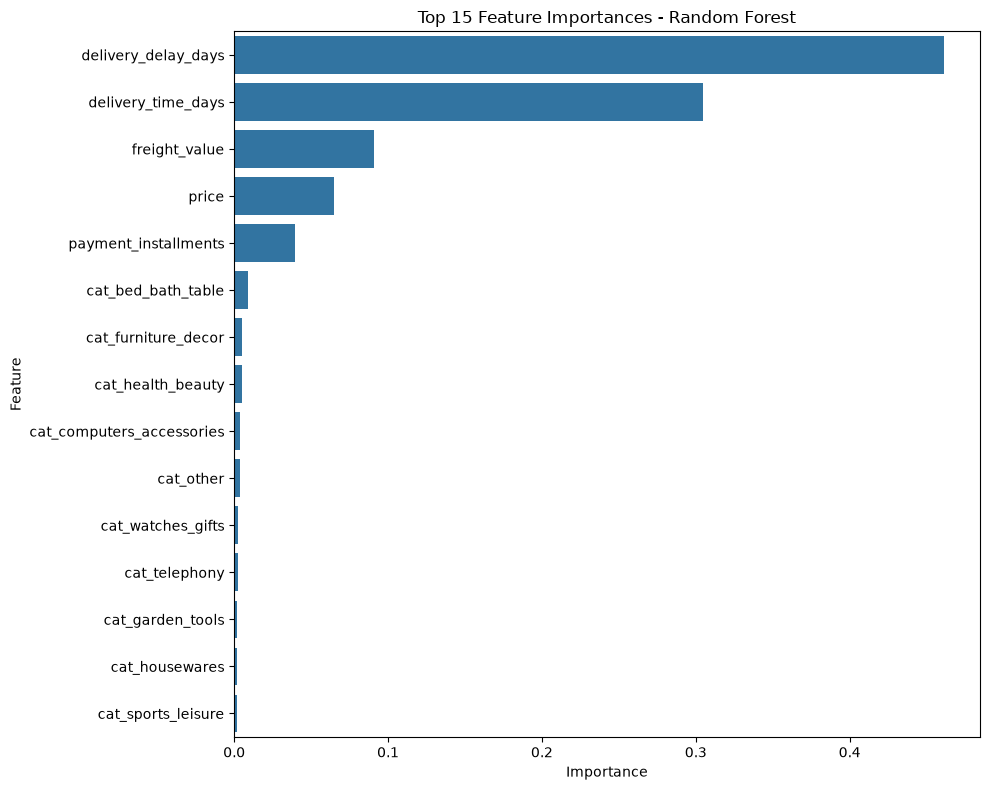

,feature,importance
0,delivery_delay_days,0.461617
1,delivery_time_days,0.304702
3,freight_value,0.090855
2,price,0.064724
4,payment_installments,0.039586
6,cat_bed_bath_table,0.008802
8,cat_furniture_decor,0.005365
10,cat_health_beauty,0.005127
7,cat_computers_accessories,0.003955
12,cat_other,0.003555


In [12]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importances.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=100, bbox_inches="tight")
plt.show()

importances.head(10)

## Summary

- Built a binary classification target: low review score (≤2), 16.34% base rate
- Trained and compared two models:
  - **Logistic Regression:** Accuracy 0.709, Precision 0.254, Recall 0.512, F1 0.34
  - **Random Forest:** Accuracy 0.835, Precision 0.434, Recall 0.426, F1 0.43
- **Random Forest selected** as the better model — best balance of precision
  and recall (F1), and highest overall accuracy
- **Top drivers of dissatisfaction risk:** delivery-related features
  (`delivery_delay_days`, `delivery_time_days`) dominate feature importance,
  confirming that late/slow delivery is the strongest predictor of a low
  review score — more so than price, freight cost, or product category
- **Business implication:** tightening delivery SLAs and proactively
  communicating delays to customers is likely the highest-leverage
  intervention to reduce dissatisfaction, ahead of pricing or product mix
  changes